In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fraud = pd.read_csv("../data/raw/Fraud_Data.csv")
credit = pd.read_csv("../data/raw/creditcard.csv")
ip_map = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [6]:
fraud.head()
credit.head()
ip_map.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [7]:
fraud.isnull().sum()
credit.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
fraud['class'].value_counts(normalize=True)
credit['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

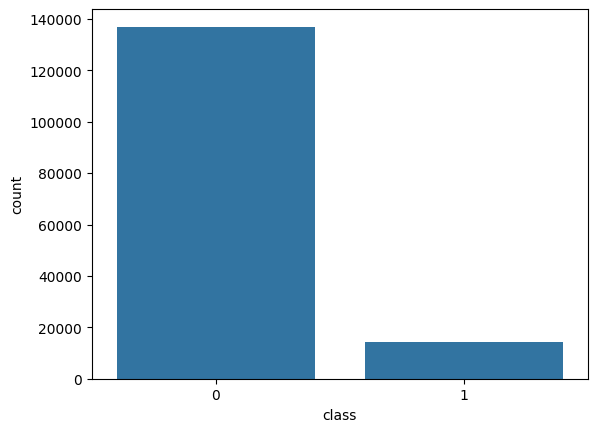

In [9]:
sns.countplot(x='class', data=fraud)
plt.show()

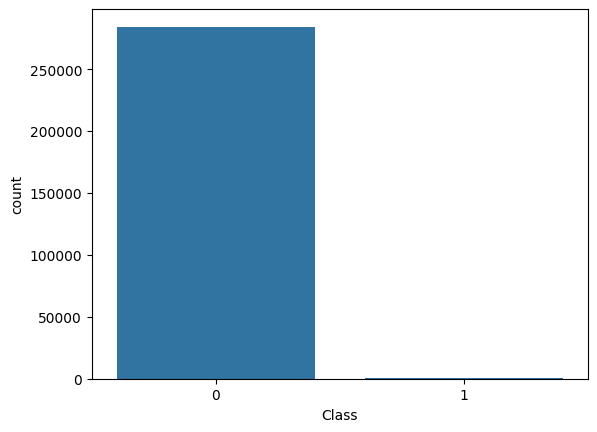

In [10]:
sns.countplot(x='Class', data=credit)
plt.show()

In [11]:
fraud['ip_address'] = fraud['ip_address'].astype(float)

In [12]:
def get_country(ip):
    match = ip_map[
        (ip_map['lower_bound_ip_address'] <= ip) &
        (ip_map['upper_bound_ip_address'] >= ip)
    ]
    return match.iloc[0]['country'] if len(match) > 0 else "Unknown"

In [13]:
fraud['country'] = fraud['ip_address'].apply(get_country)

In [14]:
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

In [15]:
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek

In [16]:
fraud['time_since_signup'] = (
    fraud['purchase_time'] - fraud['signup_time']
).dt.total_seconds()

In [17]:
fraud = fraud.drop_duplicates()
credit = credit.drop_duplicates()